# Task 2: Predict Future Stock Prices (Short-Term)

Objective: To use historical stock data to predict the next day's closing price using regression models.

In [1]:
# Installing yfinance (not pre-installed on Colab)
!pip install yfinance -q
print('yfinance installed!')

yfinance installed!


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print('All libraries imported!')

All libraries imported!


## Step 1: Load Stock Data from Yahoo Finance

In [3]:
# Choose your stock ticker — change this to any ticker you like!
TICKER = 'AAPL'  # Apple Inc.
START_DATE = '2022-01-01'
END_DATE = '2024-12-31'

print(f'Downloading data for {TICKER}...')
df = yf.download(TICKER, start=START_DATE, end=END_DATE)

print(f'\nShape: {df.shape}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
df.head()

/tmp/ipykernel_3630/1313624700.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed


Shape: (752, 5)
Date range: 2022-01-03 to 2024-12-30


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939728,178.790282,173.735900,173.853212,104487900
2022-01-04,175.681396,178.848946,175.114365,178.545881,99310400
2022-01-05,171.008286,176.140880,170.734548,175.593406,94537600
2022-01-06,168.153564,171.379770,167.801615,168.837907,96904000
2022-01-07,168.319748,170.245694,167.205242,169.023648,86709100


## Step 2: Explore the Data

In [4]:
print('Basic statistics:')
df.describe()

Basic statistics:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,752.000000,752.000000,752.000000,752.000000,7.520000e+02
mean,175.768955,177.438736,173.893905,175.575642,6.811545e+07
std,29.352588,29.274174,29.298779,29.277642,2.834590e+07
min,122.933540,125.637646,122.097746,123.907004,2.323470e+07
25%,153.223568,154.919009,150.984437,152.691689,4.877432e+07
50%,171.019325,172.033928,169.241066,170.672309,6.224455e+07
75%,189.403492,190.806976,188.110011,189.285652,8.059140e+07
max,257.375580,258.448740,255.994420,256.550862,3.186799e+08


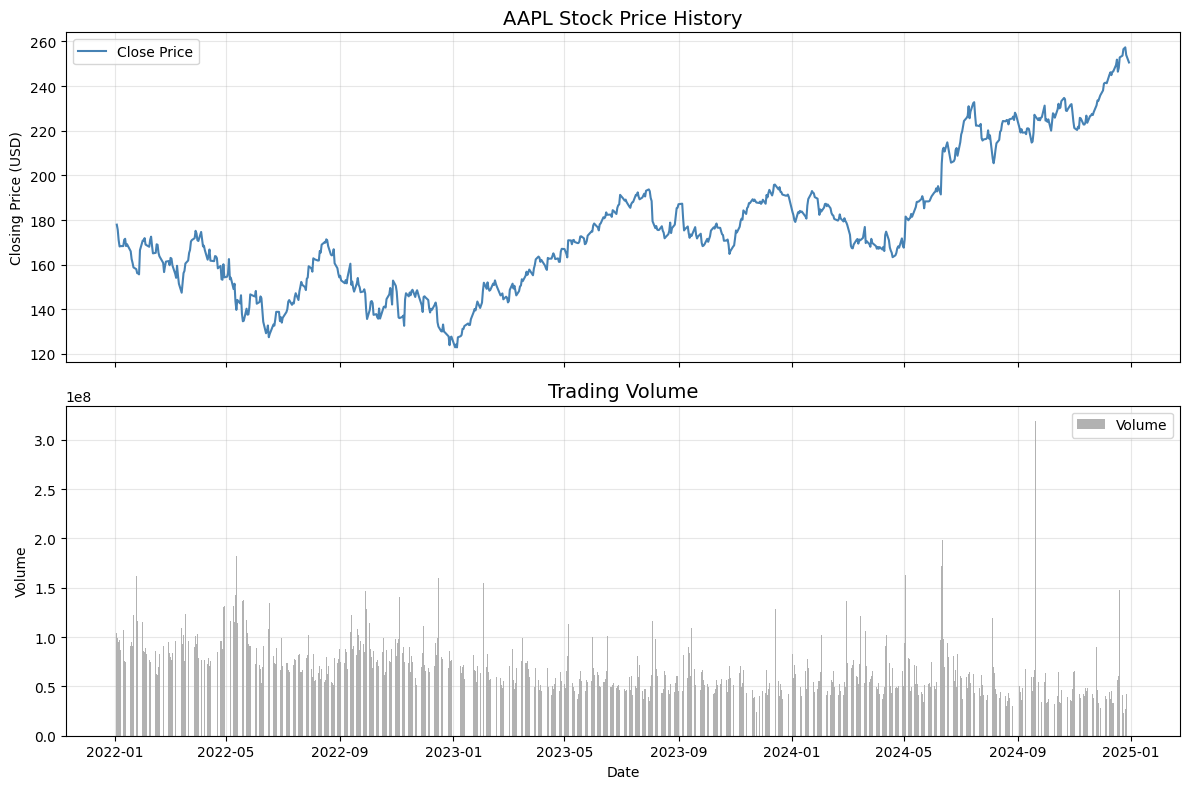

In [6]:
# Fixing MultiIndex if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

volume = pd.to_numeric(df['Volume'].squeeze(), errors='coerce')

# Plot closing price history
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(df.index, df['Close'], color='steelblue',
         linewidth=1.5, label='Close Price')
ax1.set_title(f'{TICKER} Stock Price History', fontsize=14)
ax1.set_ylabel('Closing Price (USD)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.bar(df.index, volume,
        color='gray', alpha=0.6, label='Volume')
ax2.set_title('Trading Volume', fontsize=14)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 3: Feature Engineering

We use Open, High, Low, Volume to predict the next day's Close price (target is shifted by 1 day).

In [7]:
# Flatten MultiIndex columns if present (yfinance sometimes returns them)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Feature engineering
data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Add rolling features
data['MA_5']  = data['Close'].rolling(window=5).mean()   # 5-day moving average
data['MA_10'] = data['Close'].rolling(window=10).mean()  # 10-day moving average
data['Daily_Return'] = data['Close'].pct_change()         # Daily % change
data['Price_Range']  = data['High'] - data['Low']         # Intraday range

# Target: next day's closing price
data['Target'] = data['Close'].shift(-1)

# Drop NaN rows
data.dropna(inplace=True)

print(f'Features ready. Shape after engineering: {data.shape}')
data.head()

Features ready. Shape after engineering: (742, 10)


Price,Open,High,Low,Close,Volume,MA_5,MA_10,Daily_Return,Price_Range,Target
Date,,,,,,,,,,
2022-01-14,167.508323,169.893760,167.263914,169.199646,80440800,169.729532,170.975038,0.005111,2.629846,166.002777
2022-01-18,167.674528,168.681493,165.621499,166.002777,90956700,169.262222,169.781343,-0.018894,3.059994,162.512634
2022-01-19,166.198331,167.254181,162.229126,162.512634,94815000,167.531812,168.464467,-0.021025,5.025055,160.831039
2022-01-20,163.245804,165.885420,160.508417,160.831039,91420500,165.377084,167.446742,-0.010347,5.377003,158.778030
2022-01-21,160.743075,162.610366,158.670490,158.778030,122848900,163.464825,166.509189,-0.012765,3.939876,158.005722


## Step 4: Train/Test Split and Scaling

In [8]:
feature_cols = ['Open', 'High', 'Low', 'Volume', 'MA_5', 'MA_10', 'Daily_Return', 'Price_Range']

X = data[feature_cols]
y = data['Target']

# Use 80% for training, 20% for testing (time-ordered — no shuffle)
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

Training samples: 593
Testing samples:  149


## Step 5: Train Models

In [9]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{name}:')
    print(f'  MAE  = ${mae:.2f}')
    print(f'  RMSE = ${rmse:.2f}')
    print(f'  R²   = {r2:.4f}')
    return mae, rmse, r2

print('='*40)
print('MODEL EVALUATION ON TEST SET')
print('='*40)
evaluate('Linear Regression', y_test, y_pred_lr)
print()
evaluate('Random Forest', y_test, y_pred_rf)

MODEL EVALUATION ON TEST SET
Linear Regression:
  MAE  = $2.90
  RMSE = $3.58
  R²   = 0.9305

Random Forest:
  MAE  = $30.56
  RMSE = $33.29
  R²   = -4.9997


(30.55987210984198, np.float64(33.28799174489583), -4.99969708209273)

## Step 6: Plot Actual vs Predicted Prices

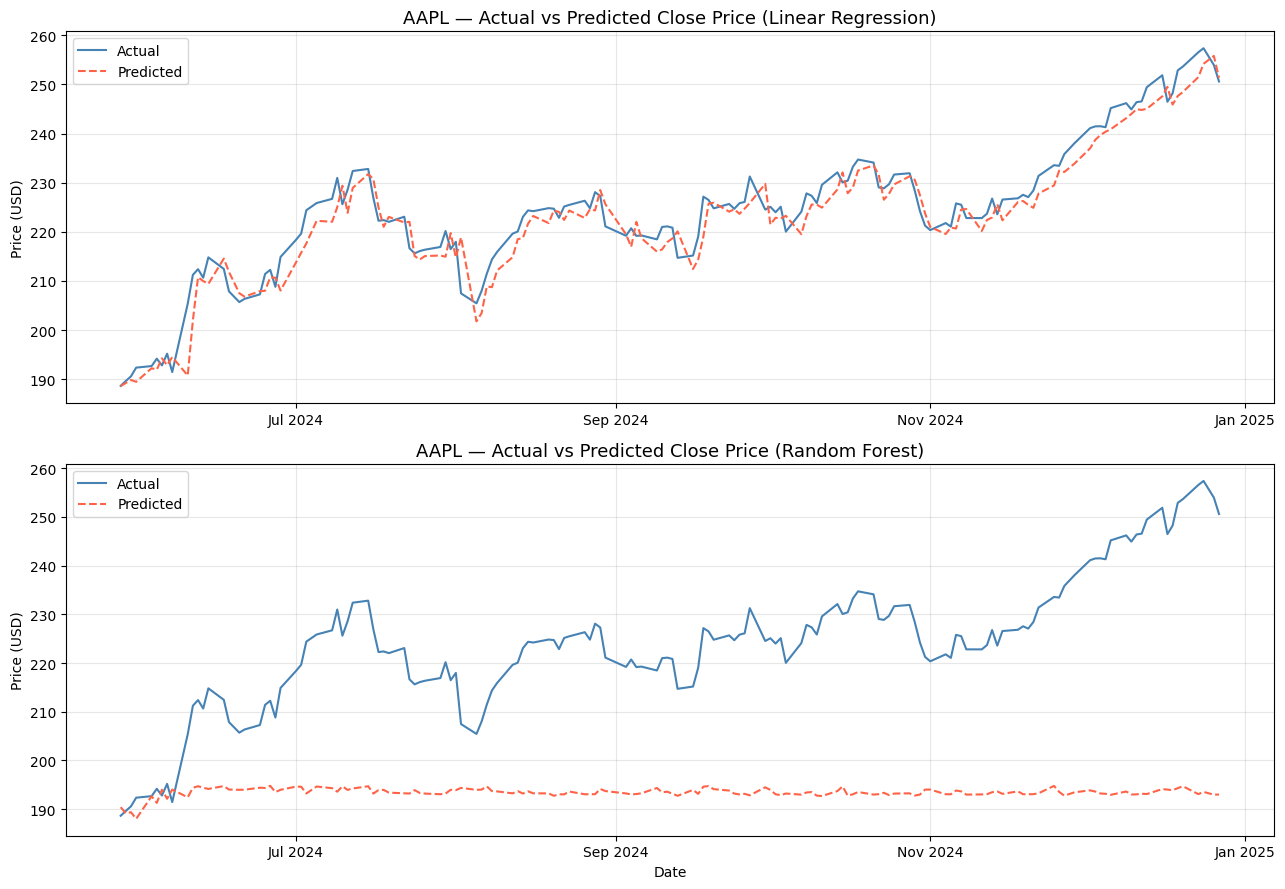

In [10]:
test_dates = data.index[split:]

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

for ax, preds, title in zip(axes,
                             [y_pred_lr, y_pred_rf],
                             ['Linear Regression', 'Random Forest']):
    ax.plot(test_dates, y_test.values, label='Actual',    color='steelblue', linewidth=1.5)
    ax.plot(test_dates, preds,         label='Predicted', color='tomato',    linewidth=1.5, linestyle='--')
    ax.set_title(f'{TICKER} — Actual vs Predicted Close Price ({title})', fontsize=13)
    ax.set_ylabel('Price (USD)')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## Step 7: Feature Importance (Random Forest)

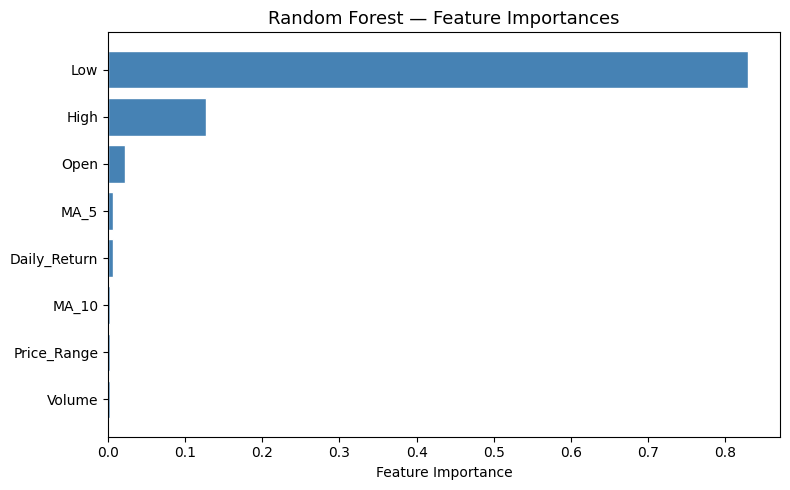

In [11]:
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance')
plt.title('Random Forest — Feature Importances', fontsize=13)
plt.tight_layout()
plt.show()